# Tesla Stock Price Prediction Using Multimodal Deep Learning

This notebook demonstrates the complete pipeline for predicting Tesla (TSLA) stock prices using:
- **Time-series data**: Historical OHLCV prices and technical indicators
- **Sentiment data**: News and social media sentiment analysis
- **Deep Learning models**: LSTM, GRU, and XGBoost comparison

## Table of Contents
1. [Setup and Imports](#1-setup-and-imports)
2. [Data Collection](#2-data-collection)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Data Preprocessing](#5-data-preprocessing)
6. [Model Training](#6-model-training)
7. [Model Comparison](#7-model-comparison)
8. [Predictions and Visualization](#8-predictions-and-visualization)
9. [Conclusions](#9-conclusions)

## 1. Setup and Imports

In [2]:
# Standard libraries
import sys
import warnings
from pathlib import Path
from datetime import datetime, timedelta

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Machine Learning
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Project modules
sys.path.append('..')
from config import *
from src.data.stock_data import fetch_stock_data, load_stock_data
from src.data.sentiment_data import fetch_sentiment_data, SentimentAnalyzer
from src.features.technical import calculate_all_indicators
from src.data.preprocessing import DataPreprocessor

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Setup device for Mac GPU (MPS) support
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = 'CUDA'
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    device_name = 'MPS (Apple Silicon GPU)'
else:
    device = torch.device('cpu')
    device_name = 'CPU'

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device_name}")
print(f"Using: {device}")

PyTorch version: 2.11.0
Device: MPS (Apple Silicon GPU)
Using: mps


## 2. Data Collection

### 2.1 Fetch Stock Data from Yahoo Finance

In [3]:
# Fetch Tesla stock data
stock_df = fetch_stock_data(
    symbol='TSLA',
    start_date='2010-06-29',
    end_date=None,  # Today
    save=True
)

print(f"\nData Shape: {stock_df.shape}")
print(f"Date Range: {stock_df['date'].min()} to {stock_df['date'].max()}")
stock_df.head(10)

Fetching TSLA data from 2010-06-29 to 2026-04-02...
Data saved to /Users/bush/Library/CloudStorage/OneDrive-UTS/UTS Master/49275 Neural Networks and Fuzzy Logic/Project/Stock price prediction using multimodal/notebooks/../data/raw/TSLA_historical.csv
Fetched 3962 rows of data

Data Shape: (3962, 10)
Date Range: 2010-06-30 00:00:00 to 2026-03-31 00:00:00


,date,open,high,low,close,volume,returns,log_returns,price_range,price_range_pct
1,2010-06-30,1.719333,2.028000,1.553333,1.588667,257806500,-0.002511,-0.002515,0.474667,0.298783
2,2010-07-01,1.666667,1.728000,1.351333,1.464000,123282000,-0.078473,-0.081723,0.376667,0.257286
3,2010-07-02,1.533333,1.540000,1.247333,1.280000,77097000,-0.125683,-0.134312,0.292667,0.228646
4,2010-07-06,1.333333,1.333333,1.055333,1.074000,103003500,-0.160937,-0.175470,0.278000,0.258845
5,2010-07-07,1.093333,1.108667,0.998667,1.053333,103825500,-0.019243,-0.019431,0.110000,0.104430
6,2010-07-08,1.076000,1.168000,1.038000,1.164000,115671000,0.105064,0.099903,0.130000,0.111684
7,2010-07-09,1.172000,1.193333,1.103333,1.160000,60759000,-0.003436,-0.003442,0.090000,0.077586
8,2010-07-12,1.196667,1.204667,1.133333,1.136667,33037500,-0.020115,-0.020320,0.071334,0.062757
9,2010-07-13,1.159333,1.242667,1.126667,1.209333,40201500,0.063929,0.061969,0.116000,0.095921
10,2010-07-14,1.196000,1.343333,1.184000,1.322667,62928000,0.093716,0.089581,0.159333,0.120463


In [4]:
# Basic statistics
stock_df.describe()

,date,open,high,low,close,volume,returns,log_returns,price_range,price_range_pct
count,3962,3962.000000,3962.000000,3962.000000,3962.000000,3.962000e+03,3962.000000,3962.000000,3962.000000,3962.000000
mean,2018-05-13 02:28:39.131751424,104.044349,106.281953,101.658296,104.012534,9.615602e+07,0.002029,0.001376,4.623657,0.042198
min,2010-06-30 00:00:00,1.076000,1.108667,0.998667,1.053333,1.777500e+06,-0.210628,-0.236518,0.016667,0.008432
25%,2014-06-06 18:00:00,12.911167,13.162500,12.650833,12.911000,5.165588e+07,-0.016549,-0.016688,0.323334,0.026690
50%,2018-05-12 12:00:00,20.165334,20.525666,19.828667,20.211666,8.221330e+07,0.001168,0.001168,0.712667,0.036684
75%,2022-04-18 18:00:00,215.219997,219.530006,209.497501,214.915833,1.201909e+08,0.019558,0.019369,7.859985,0.050801
max,2026-03-31 00:00:00,489.880005,498.829987,485.329987,489.880005,9.140820e+08,0.243951,0.218292,61.529999,0.298783
std,NaN,130.308519,133.040471,127.327577,130.208073,7.520611e+07,0.036232,0.036074,6.726993,0.024224


### 2.2 Fetch Sentiment Data

In [5]:
# Fetch sentiment data (using synthetic data based on price movements)
sentiment_df = fetch_sentiment_data(stock_df, use_real_data=False, save=True)

print(f"\nSentiment Data Shape: {sentiment_df.shape}")
sentiment_df.head(10)

Generating synthetic sentiment data...
Sentiment data saved to /Users/bush/Library/CloudStorage/OneDrive-UTS/UTS Master/49275 Neural Networks and Fuzzy Logic/Project/Stock price prediction using multimodal/notebooks/../data/raw/sentiment_data.csv

Sentiment Data Shape: (3959, 9)


,date,sentiment_compound,sentiment_positive,sentiment_negative,sentiment_neutral,news_count,sentiment_compound_lag1,sentiment_compound_lag2,sentiment_compound_lag3
4,2010-07-06,-0.897082,0.000000,0.500000,0.5,12,-0.831217,-0.663227,0.024552
5,2010-07-07,-0.212554,0.143723,0.356277,0.5,6,-0.897082,-0.831217,-0.663227
6,2010-07-08,0.772792,0.500000,0.000000,0.5,12,-0.212554,-0.897082,-0.831217
7,2010-07-09,0.122932,0.311466,0.188534,0.5,14,0.772792,-0.212554,-0.897082
8,2010-07-12,-0.123765,0.188118,0.311882,0.5,2,0.122932,0.772792,-0.212554
9,2010-07-13,0.531578,0.500000,0.000000,0.5,9,-0.123765,0.122932,0.772792
10,2010-07-14,0.757966,0.500000,0.000000,0.5,10,0.531578,-0.123765,0.122932
11,2010-07-15,-0.021140,0.239430,0.260570,0.5,17,0.757966,0.531578,-0.123765
12,2010-07-16,0.318971,0.409486,0.090514,0.5,17,-0.021140,0.757966,0.531578
13,2010-07-19,0.564565,0.500000,0.000000,0.5,3,0.318971,-0.021140,0.757966


## 3. Exploratory Data Analysis

### 3.1 Stock Price Visualization

In [6]:
# Interactive Candlestick Chart
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=[0.7, 0.3],
    subplot_titles=('TSLA Stock Price', 'Trading Volume')
)

# Candlestick chart
fig.add_trace(
    go.Candlestick(
        x=stock_df['date'],
        open=stock_df['open'],
        high=stock_df['high'],
        low=stock_df['low'],
        close=stock_df['close'],
        name='OHLC'
    ),
    row=1, col=1
)

# Volume bars
colors = ['red' if row['close'] < row['open'] else 'green' for _, row in stock_df.iterrows()]
fig.add_trace(
    go.Bar(x=stock_df['date'], y=stock_df['volume'], marker_color=colors, name='Volume'),
    row=2, col=1
)

fig.update_layout(
    title='Tesla (TSLA) Stock Price History',
    height=700,
    showlegend=False,
    xaxis_rangeslider_visible=False
)

fig.show()

### 3.2 Returns Distribution

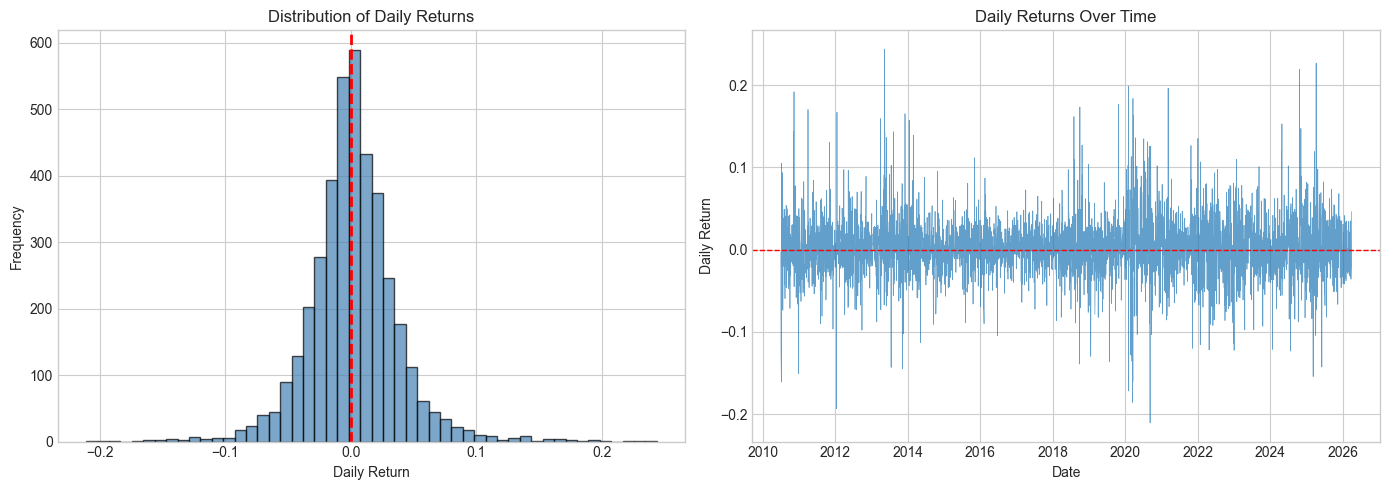

Mean Daily Return: 0.2029%
Std Daily Return: 3.6232%
Skewness: 0.3766
Kurtosis: 4.9284


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily returns distribution
axes[0].hist(stock_df['returns'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily Returns')

# Returns over time
axes[1].plot(stock_df['date'], stock_df['returns'], alpha=0.7, linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Return')
axes[1].set_title('Daily Returns Over Time')

plt.tight_layout()
plt.show()

# Statistics
print(f"Mean Daily Return: {stock_df['returns'].mean()*100:.4f}%")
print(f"Std Daily Return: {stock_df['returns'].std()*100:.4f}%")
print(f"Skewness: {stock_df['returns'].skew():.4f}")
print(f"Kurtosis: {stock_df['returns'].kurtosis():.4f}")

### 3.3 Sentiment Analysis Visualization

In [8]:
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=('Stock Price', 'Sentiment Score')
)

# Stock price
fig.add_trace(
    go.Scatter(x=stock_df['date'], y=stock_df['close'], name='Close Price', line=dict(color='blue')),
    row=1, col=1
)

# Sentiment
fig.add_trace(
    go.Scatter(
        x=sentiment_df['date'], 
        y=sentiment_df['sentiment_compound'],
        name='Sentiment',
        line=dict(color='purple'),
        fill='tozeroy',
        fillcolor='rgba(128, 0, 128, 0.2)'
    ),
    row=2, col=1
)

fig.add_hline(y=0, row=2, col=1, line_dash="dash", line_color="gray")

fig.update_layout(height=600, title='Stock Price vs Sentiment Analysis')
fig.show()

## 4. Feature Engineering

### 4.1 Technical Indicators

In [9]:
# Calculate all technical indicators
df_with_indicators = calculate_all_indicators(stock_df, add_targets=True)

print(f"Total Features: {len(df_with_indicators.columns)}")
print(f"\nFeature Categories:")
print(f"- Price features: open, high, low, close, volume")
print(f"- Moving Averages: SMA_5, SMA_10, SMA_20, SMA_50, SMA_100, SMA_200, EMA_12, EMA_26, EMA_50")
print(f"- Momentum: RSI_14, MACD, Stochastic, ROC, Momentum")
print(f"- Volatility: Bollinger Bands, ATR, Parkinson Vol")
print(f"- Volume: OBV, VWAP")
print(f"- Price Patterns: Body, Shadows, Gaps")
print(f"\nAll columns:")
print(df_with_indicators.columns.tolist())

Calculating technical indicators...
Added 53 features
Total Features: 53

Feature Categories:
- Price features: open, high, low, close, volume
- Moving Averages: SMA_5, SMA_10, SMA_20, SMA_50, SMA_100, SMA_200, EMA_12, EMA_26, EMA_50
- Momentum: RSI_14, MACD, Stochastic, ROC, Momentum
- Volatility: Bollinger Bands, ATR, Parkinson Vol
- Volume: OBV, VWAP
- Price Patterns: Body, Shadows, Gaps

All columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns', 'price_range', 'price_range_pct', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_100', 'SMA_200', 'EMA_12', 'EMA_26', 'EMA_50', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position', 'ATR_14', 'OBV', 'OBV_SMA', 'VWAP', 'Stoch_K', 'Stoch_D', 'Momentum_5', 'Momentum_10', 'Momentum_20', 'ROC_10', 'ROC_20', 'Price_Acceleration', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Parkinson_Vol', 'Body', 'Body_Pct', 'Upper_Shadow', 'Lower_Shadow', 'Gap', 'Gap_Pct',

### 4.2 Technical Indicators Visualization

In [10]:
# Create subplots for key indicators
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=('Price with Moving Averages', 'RSI (14)', 'MACD', 'Bollinger Bands'),
    row_heights=[0.35, 0.2, 0.2, 0.25]
)

# Price with MAs
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['close'], name='Close', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['SMA_20'], name='SMA 20', line=dict(color='orange')), row=1, col=1)
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['SMA_50'], name='SMA 50', line=dict(color='red')), row=1, col=1)

# RSI
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['RSI_14'], name='RSI', line=dict(color='purple')), row=2, col=1)
fig.add_hline(y=70, row=2, col=1, line_dash="dash", line_color="red")
fig.add_hline(y=30, row=2, col=1, line_dash="dash", line_color="green")

# MACD
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['MACD'], name='MACD', line=dict(color='blue')), row=3, col=1)
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['MACD_Signal'], name='Signal', line=dict(color='orange')), row=3, col=1)
fig.add_trace(go.Bar(x=df_with_indicators['date'], y=df_with_indicators['MACD_Hist'], name='Histogram', marker_color='gray'), row=3, col=1)

# Bollinger Bands
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['close'], name='Close', line=dict(color='blue')), row=4, col=1)
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['BB_Upper'], name='Upper BB', line=dict(color='red', dash='dash')), row=4, col=1)
fig.add_trace(go.Scatter(x=df_with_indicators['date'], y=df_with_indicators['BB_Lower'], name='Lower BB', line=dict(color='green', dash='dash'), fill='tonexty', fillcolor='rgba(0,100,80,0.1)'), row=4, col=1)

fig.update_layout(height=1000, title='Technical Indicators Dashboard', showlegend=True)
fig.show()

### 4.3 Feature Correlation Analysis

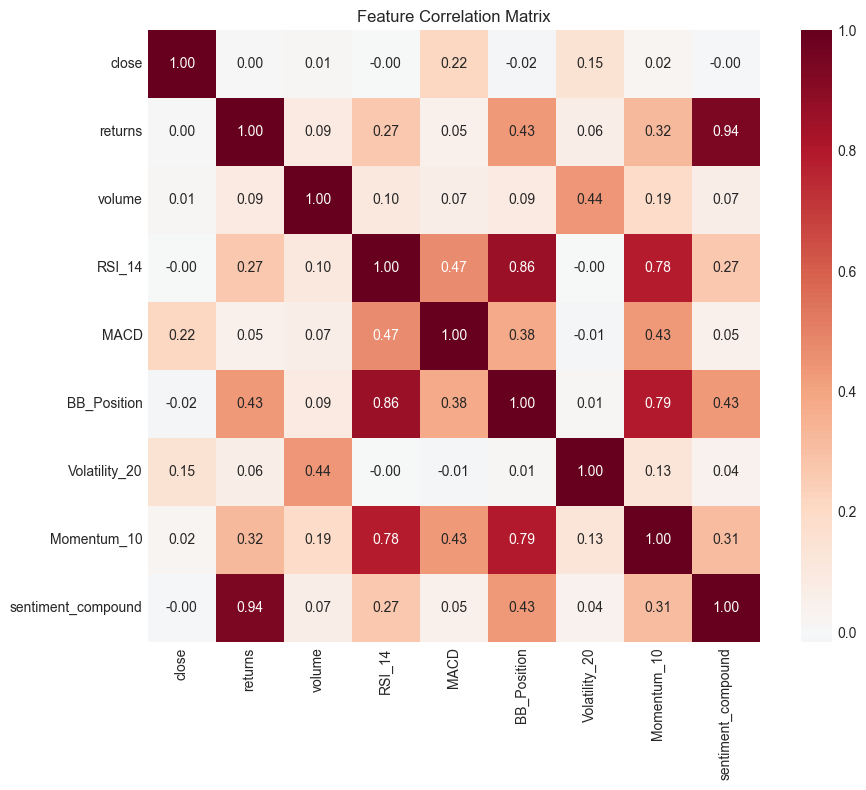

In [11]:
# Select key features for correlation analysis
key_features = ['close', 'returns', 'volume', 'RSI_14', 'MACD', 'BB_Position', 
                'Volatility_20', 'Momentum_10', 'sentiment_compound']

# Merge with sentiment
merged_df = df_with_indicators.merge(
    sentiment_df[['date', 'sentiment_compound']], 
    on='date', 
    how='left'
).dropna()

# Correlation matrix
available_features = [f for f in key_features if f in merged_df.columns]
corr_matrix = merged_df[available_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

### 5.1 Prepare Data for Training

In [12]:
# Initialize preprocessor
preprocessor = DataPreprocessor(sequence_length=60)

# Prepare data
splits = preprocessor.prepare_data(stock_df, sentiment_df, df_with_indicators)

print(f"Training set: {splits['train']['X_price'].shape}")
print(f"Validation set: {splits['val']['X_price'].shape}")
print(f"Test set: {splits['test']['X_price'].shape}")
print(f"\nNumber of price features: {splits['train']['X_price'].shape[2]}")
if splits['train']['X_sentiment'] is not None:
    print(f"Number of sentiment features: {splits['train']['X_sentiment'].shape[2]}")

Starting data preprocessing...
Scalers fitted and saved
Train: 3120 samples
Val: 390 samples
Test: 391 samples
Data preprocessing complete!
Training set: (3120, 60, 50)
Validation set: (390, 60, 50)
Test set: (391, 60, 50)

Number of price features: 50
Number of sentiment features: 7


In [13]:
# Combine features for training
X_train = splits['train']['X_price']
X_val = splits['val']['X_price']
X_test = splits['test']['X_price']

if splits['train']['X_sentiment'] is not None:
    X_train = np.concatenate([X_train, splits['train']['X_sentiment']], axis=2)
    X_val = np.concatenate([X_val, splits['val']['X_sentiment']], axis=2)
    X_test = np.concatenate([X_test, splits['test']['X_sentiment']], axis=2)

y_train = splits['train']['y_reg']
y_val = splits['val']['y_reg']
y_test = splits['test']['y_reg']

print(f"Combined X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Combined X_train shape: (3120, 60, 57)
y_train shape: (3120,)


## 6. Model Training

### 6.1 Import Models

In [14]:
from src.models.regression_models import LSTMRegressor, GRURegressor, XGBoostRegressor, MultiModelRegressor

# Initialize multi-model system
input_size = X_train.shape[2]
multi_model = MultiModelRegressor(input_size=input_size)

print(f"Input size: {input_size}")
print(f"Models to train: {list(multi_model.models.keys())}")

Using device: mps
Input size: 57
Models to train: ['LSTM', 'GRU', 'XGBoost']


### 6.2 Train All Models

Training all models...


Training LSTM...
  Epoch    Train Loss      Val Loss        Status
  --------------------------------------------------
  1        0.012623        0.043091        ✓ Best
  2        0.008227        0.024366        ✓ Best
  4        0.007898        0.016868        ✓ Best
  7        0.007480        0.015722        ✓ Best
  9        0.007085        0.014314        ✓ Best
  10       0.006926        0.013035        ✓ Best
  11       0.006961        0.011009        ✓ Best
  15       0.006781        0.010573        ✓ Best
  17       0.006392        0.007586        ✓ Best
  19       0.006156        0.006740        ✓ Best
  21       0.005812        0.006750        
  22       0.005520        0.006247        ✓ Best
  25       0.005219        0.006032        ✓ Best
  28       0.005221        0.005695        ✓ Best
  31       0.004461        0.005866        
  41       0.002881        0.006088        
  50       0.001910        0.005917        
  ---------------------------

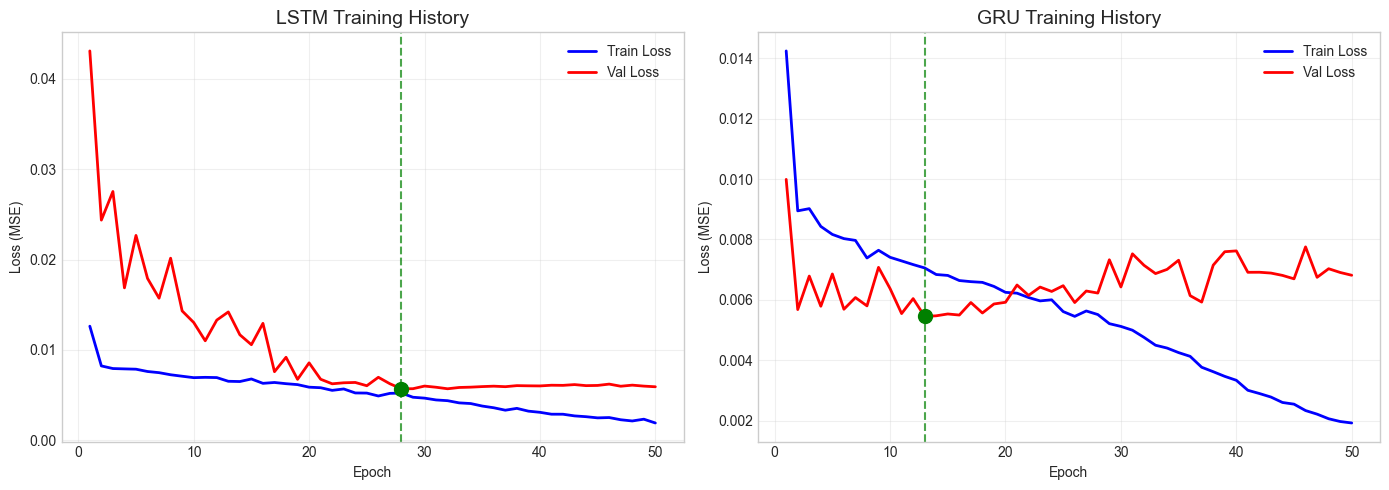

In [15]:
# Train all models (LSTM, GRU, XGBoost)
print("Training all models...\n")
multi_model.train_all(X_train, y_train, X_val, y_val, epochs=50)

print("\n✅ All models trained successfully!")

## 7. Model Comparison

### 7.1 Evaluate All Models

In [16]:
# Evaluate on test set
results = multi_model.evaluate_all(X_test, y_test)

# Create comparison DataFrame
comparison_data = []
for model_name, metrics in results.items():
    comparison_data.append({
        'Model': model_name,
        'RMSE': metrics['RMSE'],
        'MAE': metrics['MAE'],
        'MAPE (%)': metrics['MAPE'],
        'Directional Accuracy (%)': metrics['Directional_Accuracy']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('RMSE')

print("\n" + "="*60)
print("MODEL COMPARISON - TEST SET RESULTS")
print("="*60)
display(comparison_df.style.highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)'], color='lightgreen')
                           .highlight_max(subset=['Directional Accuracy (%)'], color='lightgreen'))


MODEL COMPARISON - TEST SET RESULTS


,Model,RMSE,MAE,MAPE (%),Directional Accuracy (%)
0,LSTM,0.091940,0.069100,nan,100.000000
2,XGBoost,0.092878,0.069597,nan,100.000000
1,GRU,0.101347,0.074613,nan,100.000000


### 7.2 Model Performance Visualization

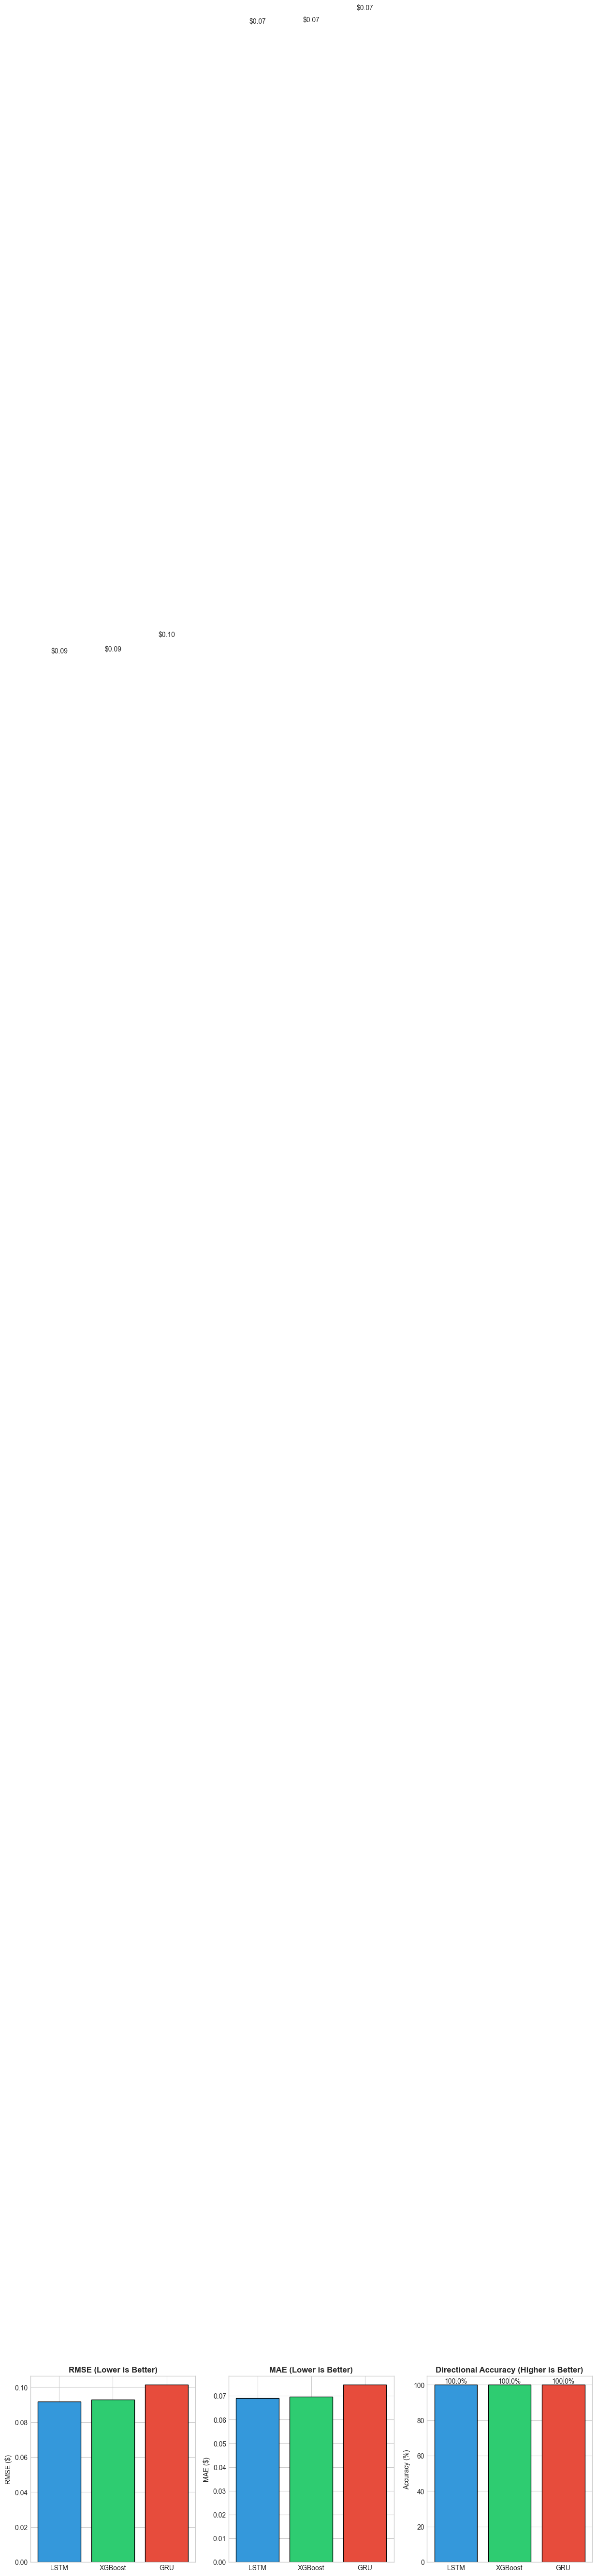

In [17]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = comparison_df['Model'].tolist()
colors = ['#3498db', '#2ecc71', '#e74c3c']

# RMSE
bars1 = axes[0].bar(models, comparison_df['RMSE'], color=colors, edgecolor='black')
axes[0].set_title('RMSE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
for bar, val in zip(bars1, comparison_df['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'${val:.2f}', ha='center', fontsize=10)

# MAE
bars2 = axes[1].bar(models, comparison_df['MAE'], color=colors, edgecolor='black')
axes[1].set_title('MAE (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE ($)')
for bar, val in zip(bars2, comparison_df['MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'${val:.2f}', ha='center', fontsize=10)

# Directional Accuracy
bars3 = axes[2].bar(models, comparison_df['Directional Accuracy (%)'], color=colors, edgecolor='black')
axes[2].set_title('Directional Accuracy (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Accuracy (%)')
for bar, val in zip(bars3, comparison_df['Directional Accuracy (%)']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../models/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predictions and Visualization

### 8.1 Get Predictions from All Models

In [18]:
# Get predictions from all models
predictions = {}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for model_name, model in multi_model.models.items():
    if model_name == 'XGBoost':
        preds = model.predict(X_test)
    else:
        model.eval()
        with torch.no_grad():
            X_t = torch.FloatTensor(X_test).to(device)
            preds = model(X_t).cpu().numpy()
    predictions[model_name] = preds

print("Predictions generated for all models!")

RuntimeError: Tensor for argument input is on cpu but expected on mps

### 8.2 Actual vs Predicted Comparison

In [1]:
# Plot actual vs predicted for all models
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=['LSTM Predictions', 'GRU Predictions', 'XGBoost Predictions']
)

test_dates = splits['test']['dates']

for i, (model_name, preds) in enumerate(predictions.items(), 1):
    # Actual values
    fig.add_trace(
        go.Scatter(x=list(range(len(y_test))), y=y_test, name='Actual', 
                   line=dict(color='blue'), showlegend=(i==1)),
        row=i, col=1
    )
    # Predictions
    fig.add_trace(
        go.Scatter(x=list(range(len(preds))), y=preds, name=f'{model_name}', 
                   line=dict(color='red', dash='dash')),
        row=i, col=1
    )

fig.update_layout(height=800, title='Actual vs Predicted Stock Prices')
fig.show()

NameError: name 'make_subplots' is not defined

### 8.3 Prediction Error Analysis

In [ ]:
# Calculate and visualize errors
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (model_name, preds) in enumerate(predictions.items()):
    errors = y_test - preds
    
    axes[i].hist(errors, bins=30, edgecolor='black', alpha=0.7, color=['#3498db', '#2ecc71', '#e74c3c'][i])
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'{model_name} Prediction Errors')
    axes[i].set_xlabel('Error ($)')
    axes[i].set_ylabel('Frequency')
    
    # Add statistics
    stats_text = f'Mean: ${np.mean(errors):.2f}\nStd: ${np.std(errors):.2f}'
    axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../models/prediction_errors.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Ensemble Prediction

In [ ]:
# Create ensemble prediction (average of all models)
ensemble_pred = np.mean([predictions['LSTM'], predictions['GRU'], predictions['XGBoost']], axis=0)

# Calculate ensemble metrics
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_r2 = r2_score(y_test, ensemble_pred)

print("\n" + "="*50)
print("ENSEMBLE MODEL RESULTS")
print("="*50)
print(f"RMSE: ${ensemble_rmse:.2f}")
print(f"MAE: ${ensemble_mae:.2f}")
print(f"R² Score: {ensemble_r2:.4f}")

# Compare with individual models
print("\n" + "-"*50)
print("Comparison with Individual Models (RMSE):")
print("-"*50)
for model_name, metrics in results.items():
    improvement = ((metrics['RMSE'] - ensemble_rmse) / metrics['RMSE']) * 100
    print(f"{model_name}: ${metrics['RMSE']:.2f} (Ensemble {'better' if improvement > 0 else 'worse'} by {abs(improvement):.1f}%)")

In [ ]:
# Visualize ensemble vs individual models
fig = go.Figure()

fig.add_trace(go.Scatter(x=list(range(len(y_test))), y=y_test, name='Actual', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=list(range(len(y_test))), y=predictions['LSTM'], name='LSTM', line=dict(color='green', dash='dot')))
fig.add_trace(go.Scatter(x=list(range(len(y_test))), y=predictions['GRU'], name='GRU', line=dict(color='orange', dash='dot')))
fig.add_trace(go.Scatter(x=list(range(len(y_test))), y=predictions['XGBoost'], name='XGBoost', line=dict(color='purple', dash='dot')))
fig.add_trace(go.Scatter(x=list(range(len(y_test))), y=ensemble_pred, name='Ensemble', line=dict(color='red', width=3)))

fig.update_layout(
    title='Model Comparison: Individual vs Ensemble Predictions',
    xaxis_title='Sample Index',
    yaxis_title='Stock Price ($)',
    height=500
)

fig.show()

### 8.5 Save Models and Results

In [ ]:
# Save models
multi_model.save_models(MODELS_DIR)

# Save comparison results
comparison_df.to_csv(MODELS_DIR / 'model_comparison.csv', index=False)

print("✅ Models and results saved successfully!")

## 9. Conclusions

### Key Findings

In [ ]:
# Summary
best_model = comparison_df.iloc[0]['Model']
best_rmse = comparison_df.iloc[0]['RMSE']

print("="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"\n📊 Data:")
print(f"   - Stock data points: {len(stock_df)}")
print(f"   - Date range: {stock_df['date'].min().strftime('%Y-%m-%d')} to {stock_df['date'].max().strftime('%Y-%m-%d')}")
print(f"   - Features used: {X_train.shape[2]}")
print(f"   - Sequence length: 60 days")

print(f"\n🧠 Models Trained:")
print(f"   - LSTM (Bidirectional with Attention)")
print(f"   - GRU (Bidirectional with Attention)")
print(f"   - XGBoost (Gradient Boosting)")

print(f"\n🏆 Best Model: {best_model}")
print(f"   - RMSE: ${best_rmse:.2f}")

print(f"\n📈 Ensemble Model:")
print(f"   - RMSE: ${ensemble_rmse:.2f}")
print(f"   - R² Score: {ensemble_r2:.4f}")

print("\n" + "="*60)
print("⚠️  DISCLAIMER: This is for educational purposes only.")
print("    Do not use for actual trading decisions.")
print("="*60)

### Future Improvements

1. **Data Enhancements**:
   - Real-time news sentiment from APIs
   - Social media sentiment (Twitter, Reddit)
   - Macroeconomic indicators

2. **Model Improvements**:
   - Transformer-based models (temporal attention)
   - Hyperparameter tuning with Optuna
   - More sophisticated ensemble methods

3. **Evaluation**:
   - Backtesting with trading simulation
   - Risk-adjusted metrics (Sharpe ratio)
   - Walk-forward validation